In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("water_data.csv")

# Display the first 5 rows
df.head()

,timestamp,fault_d7,4700008966_kW,4700008966_power_hour,4408411600_kW,4408411600_power_hour,4608927500_kvar_hour,238045_ws_temp,279805_ws_vigor,279804_ws_level,279625_ws_temp,279623_ws_vigor,319235_ws_temp,279831_ws_temp,326417_ws_temp,326416_ws_vigor,temp_site1_anomaly_score,sfc_temp_site1_anomaly_score,gw_lvl_site2_anomaly_score,gw_temp_site2_anomaly_score
0,31-12-2021 23:00,0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01-01-2022 0:00,0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.34,7.63,9.48,38.44
2,01-01-2022 1:00,0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.96,0.87,9.48,38.44
3,01-01-2022 2:00,0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.01,1.23,9.48,38.44
4,01-01-2022 3:00,0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.51,4.86,9.48,38.44


In [ ]:
# Basic information about our dataset

print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget variable distribution:")
print(df["fault_d7"].value_counts())

print("\nTarget variable percentage:")
print(df["fault_d7"].value_counts(normalize=True) * 100)

Shape of dataset: (8737, 20)

Column names:
['timestamp', 'fault_d7', '4700008966_kW', '4700008966_power_hour', '4408411600_kW', '4408411600_power_hour', '4608927500_kvar_hour', '238045_ws_temp', '279805_ws_vigor', '279804_ws_level', '279625_ws_temp', '279623_ws_vigor', '319235_ws_temp', '279831_ws_temp', '326417_ws_temp', '326416_ws_vigor', 'temp_site1_anomaly_score', 'sfc_temp_site1_anomaly_score', 'gw_lvl_site2_anomaly_score', 'gw_temp_site2_anomaly_score']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8737 entries, 0 to 8736
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   timestamp                     8737 non-null   object 
 1   fault_d7                      8737 non-null   int64  
 2   4700008966_kW                 8737 non-null   float64
 3   4700008966_power_hour         8737 non-null   float64
 4   4408411600_kW                 6578 non-null   f

In [ ]:
# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%d-%m-%Y %H:%M"
)

# Check the time range
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

# Check target distribution again
print("\nTarget distribution:")
print(df["fault_d7"].value_counts())

# Check how many unique periods have fault_d7 = 1
print("\nFirst 20 leak-proximity timestamps:")
print(df.loc[df["fault_d7"] == 1, ["timestamp", "fault_d7"]].head(20))

Start: 2021-12-31 23:00:00
End: 2022-12-30 23:00:00

Target distribution:
fault_d7
1    6432
0    2305
Name: count, dtype: int64

First 20 leak-proximity timestamps:
             timestamp  fault_d7
49 2022-03-01 00:00:00         1
50 2022-03-01 01:00:00         1
51 2022-03-01 02:00:00         1
52 2022-03-01 03:00:00         1
53 2022-03-01 04:00:00         1
54 2022-03-01 05:00:00         1
55 2022-03-01 06:00:00         1
56 2022-03-01 07:00:00         1
57 2022-03-01 08:00:00         1
58 2022-03-01 09:00:00         1
59 2022-03-01 10:00:00         1
60 2022-03-01 11:00:00         1
61 2022-03-01 12:00:00         1
62 2022-03-01 13:00:00         1
63 2022-03-01 14:00:00         1
64 2022-03-01 15:00:00         1
65 2022-03-01 16:00:00         1
66 2022-03-01 17:00:00         1
67 2022-03-01 18:00:00         1
68 2022-03-01 19:00:00         1


In [ ]:
# Identify continuous periods where fault_d7 stays the same
df = df.sort_values("timestamp").reset_index(drop=True)

df["group"] = (df["fault_d7"] != df["fault_d7"].shift()).cumsum()

periods = df.groupby("group").agg(
    label=("fault_d7", "first"),
    start=("timestamp", "first"),
    end=("timestamp", "last"),
    hours=("fault_d7", "size")
).reset_index(drop=True)

# Show all periods where fault_d7 = 1
leak_periods = periods[periods["label"] == 1]

print("Number of leak-proximity periods:", len(leak_periods))
print()
print(leak_periods.to_string(index=False))

Number of leak-proximity periods: 34

 label      start                 end  hours
     1 2022-01-02 2022-01-03 23:00:00     48
     1 2022-01-06 2022-01-06 23:00:00     24
     1 2022-01-08 2022-01-10 23:00:00     72
     1 2022-01-12 2022-01-31 23:00:00    480
     1 2022-02-02 2022-02-03 23:00:00     48
     1 2022-02-06 2022-02-06 23:00:00     24
     1 2022-02-08 2022-02-15 23:00:00    192
     1 2022-02-26 2022-03-03 23:00:00    144
     1 2022-03-06 2022-03-06 23:00:00     24
     1 2022-03-08 2022-03-16 23:00:00    216
     1 2022-04-01 2022-04-03 23:00:00     72
     1 2022-04-06 2022-04-06 23:00:00     24
     1 2022-04-08 2022-04-19 23:00:00    288
     1 2022-05-01 2022-05-04 23:00:00     96
     1 2022-05-06 2022-05-06 23:00:00     24
     1 2022-05-08 2022-05-12 23:00:00    120
     1 2022-05-30 2022-06-04 23:00:00    144
     1 2022-06-06 2022-06-06 23:00:00     24
     1 2022-06-08 2022-07-04 23:00:00    648
     1 2022-07-06 2022-07-06 23:00:00     24
     1 2022-07-08

In [ ]:
# Check whether we have every expected hourly timestamp

time_diff = df["timestamp"].diff()

print("Most common time difference:")
print(time_diff.value_counts().head(10))

print("\nNumber of gaps larger than 1 hour:")
print((time_diff > pd.Timedelta(hours=1)).sum())

print("\nLargest time gap:")
print(time_diff.max())

# Show the largest gaps
print("\nLargest gaps in the dataset:")
print(
    df.loc[time_diff > pd.Timedelta(hours=1),
           ["timestamp", "fault_d7"]]
)

Most common time difference:
timestamp
0 days 01:00:00    8736
Name: count, dtype: int64

Number of gaps larger than 1 hour:
0

Largest time gap:
0 days 01:00:00

Largest gaps in the dataset:
Empty DataFrame
Columns: [timestamp, fault_d7]
Index: []


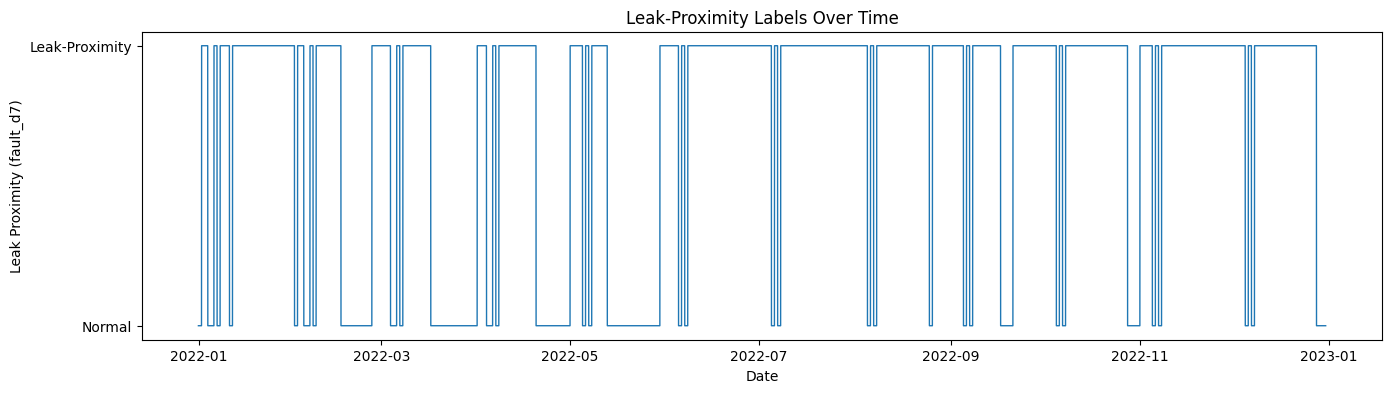

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))

plt.plot(
    df["timestamp"],
    df["fault_d7"],
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Leak Proximity (fault_d7)")
plt.title("Leak-Proximity Labels Over Time")
plt.yticks([0, 1], ["Normal", "Leak-Proximity"])

plt.show()

In [ ]:
# Create month column
df["month"] = df["timestamp"].dt.to_period("M")

# Calculate percentage of leak-proximity observations each month
monthly_summary = df.groupby("month")["fault_d7"].agg(
    total_hours="count",
    leak_proximity_hours="sum",
    leak_proximity_percentage="mean"
)

monthly_summary["leak_proximity_percentage"] *= 100

print(monthly_summary)

         total_hours  leak_proximity_hours  leak_proximity_percentage
month                                                                
2021-12            1                     0                   0.000000
2022-01          744                   624                  83.870968
2022-02          672                   336                  50.000000
2022-03          744                   312                  41.935484
2022-04          720                   384                  53.333333
2022-05          744                   288                  38.709677
2022-06          720                   672                  93.333333
2022-07          744                   696                  93.548387
2022-08          744                   672                  90.322581
2022-09          720                   576                  80.000000
2022-10          744                   600                  80.645161
2022-11          720                   672                  93.333333
2022-12          720

In [ ]:
# Compare feature averages between the two target classes

numeric_features = df.select_dtypes(include=["float64", "int64"]).columns
numeric_features = numeric_features.drop("fault_d7")

class_means = df.groupby("fault_d7")[numeric_features].mean().T

class_means.columns = ["Normal (0)", "Leak-Proximity (1)"]

class_means["Difference (%)"] = (
    (class_means["Leak-Proximity (1)"] - class_means["Normal (0)"])
    / class_means["Normal (0)"].replace(0, np.nan)
) * 100

print(class_means.sort_values("Difference (%)", ascending=False))

                              Normal (0)  Leak-Proximity (1)  Difference (%)
279805_ws_vigor                 0.045784            1.158476     2430.288248
326416_ws_vigor                 0.394636            2.895587      633.736609
4700008966_power_hour           0.247291            1.581247      539.426595
4700008966_kW                   0.271203            1.581247      483.049473
238045_ws_temp                  0.035147            0.135632      285.899238
279831_ws_temp                  0.170472            0.559326      228.105108
4408411600_kW                   0.080371            0.224293      179.071731
279804_ws_level                 0.219601            0.420107       91.305110
gw_lvl_site2_anomaly_score     20.153913           37.379906       85.472199
279623_ws_vigor                 0.188066            0.339208       80.366210
279625_ws_temp                  0.184465            0.320808       73.912673
temp_site1_anomaly_score        9.012969           14.455250       60.382785

In [ ]:
# Remove columns that we created during analysis
df = df.drop(columns=["group", "month"], errors="ignore")

# Separate features and target
features = [col for col in df.columns
            if col not in ["timestamp", "fault_d7"]]

# Missing values by target class
missing_by_class = df.groupby("fault_d7")[features].apply(
    lambda x: x.isnull().sum()
)

print("Missing values by target class:")
print(missing_by_class)

Missing values by target class:
          4700008966_kW  4700008966_power_hour  4408411600_kW  \
fault_d7                                                        
0                     0                      0            647   
1                     0                      0           1512   

          4408411600_power_hour  4608927500_kvar_hour  238045_ws_temp  \
fault_d7                                                                
0                           647                     0               0   
1                          1512                     0               0   

          279805_ws_vigor  279804_ws_level  279625_ws_temp  279623_ws_vigor  \
fault_d7                                                                      
0                      13               13              49               49   
1                       0                0             432              432   

          319235_ws_temp  279831_ws_temp  326417_ws_temp  326416_ws_vigor  \
fault_d7            

In [ ]:
# Percentage of missing values by target class
missing_percentage = df.groupby("fault_d7")[features].apply(
    lambda x: x.isnull().mean() * 100
)

print("Missing percentage by target class:")
print(missing_percentage.round(2))

Missing percentage by target class:
          4700008966_kW  4700008966_power_hour  4408411600_kW  \
fault_d7                                                        
0                   0.0                    0.0          28.07   
1                   0.0                    0.0          23.51   

          4408411600_power_hour  4608927500_kvar_hour  238045_ws_temp  \
fault_d7                                                                
0                         28.07                   0.0             0.0   
1                         23.51                   0.0             0.0   

          279805_ws_vigor  279804_ws_level  279625_ws_temp  279623_ws_vigor  \
fault_d7                                                                      
0                    0.56             0.56            2.13             2.13   
1                    0.00             0.00            6.72             6.72   

          319235_ws_temp  279831_ws_temp  326417_ws_temp  326416_ws_vigor  \
fault_d7        

In [ ]:
# Calculate correlation between numerical features and fault_d7

correlations = (
    df[features + ["fault_d7"]]
    .corr()["fault_d7"]
    .drop("fault_d7")
    .sort_values(key=abs, ascending=False)
)

print("Feature correlations with fault_d7:")
print(correlations)

Feature correlations with fault_d7:
gw_lvl_site2_anomaly_score      0.322364
gw_temp_site2_anomaly_score     0.254486
temp_site1_anomaly_score        0.151121
sfc_temp_site1_anomaly_score    0.126008
326416_ws_vigor                 0.084023
279805_ws_vigor                 0.078704
4700008966_power_hour           0.068181
4700008966_kW                   0.066722
326417_ws_temp                  0.065078
319235_ws_temp                  0.053844
279831_ws_temp                  0.049518
238045_ws_temp                  0.020312
4408411600_kW                   0.020040
279623_ws_vigor                 0.018807
279804_ws_level                 0.018431
279625_ws_temp                  0.017556
4408411600_power_hour          -0.012934
4608927500_kvar_hour           -0.007352
Name: fault_d7, dtype: float64


In [ ]:
# Make sure the data is sorted chronologically
df = df.sort_values("timestamp").reset_index(drop=True)

# Features and target
features = [
    col for col in df.columns
    if col not in ["timestamp", "fault_d7"]
]

X = df[features]
y = df["fault_d7"]

# 80/20 chronological split
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(df["timestamp"].iloc[0], "→", df["timestamp"].iloc[split_index - 1])

print("\nTesting period:")
print(df["timestamp"].iloc[split_index], "→", df["timestamp"].iloc[-1])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training samples: 6989
Testing samples: 1748

Training period:
2021-12-31 23:00:00 → 2022-10-19 03:00:00

Testing period:
2022-10-19 04:00:00 → 2022-12-30 23:00:00

Training target distribution:
fault_d7
1    70.796967
0    29.203033
Name: proportion, dtype: float64

Testing target distribution:
fault_d7
1    84.897025
0    15.102975
Name: proportion, dtype: float64


In [ ]:
# Examine target transitions in the training and testing periods

def count_transitions(series):
    return (series != series.shift()).sum() - 1

print("Target transitions in training:", count_transitions(y_train))
print("Target transitions in testing:", count_transitions(y_test))

print("\nTraining target counts:")
print(y_train.value_counts())

print("\nTesting target counts:")
print(y_test.value_counts())

Target transitions in training: 57
Target transitions in testing: 11

Training target counts:
fault_d7
1    4948
0    2041
Name: count, dtype: int64

Testing target counts:
fault_d7
1    1484
0     264
Name: count, dtype: int64


In [ ]:
# Show the first and last few target transitions in the test period

test_df = df.iloc[split_index:].copy()

test_df["target_change"] = (
    test_df["fault_d7"] != test_df["fault_d7"].shift()
)

print(test_df[test_df["target_change"]][
    ["timestamp", "fault_d7"]
].to_string(index=False))

          timestamp  fault_d7
2022-10-19 04:00:00         1
2022-10-28 00:00:00         0
2022-11-01 00:00:00         1
2022-11-05 00:00:00         0
2022-11-06 00:00:00         1
2022-11-07 00:00:00         0
2022-11-08 00:00:00         1
2022-12-05 00:00:00         0
2022-12-06 00:00:00         1
2022-12-07 00:00:00         0
2022-12-08 00:00:00         1
2022-12-28 00:00:00         0


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

In [ ]:
# Create preprocessing + Logistic Regression pipeline

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [ ]:
# Make predictions on the test data

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions completed.")

Predictions completed.


In [ ]:
# Evaluate the Logistic Regression baseline

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob), 4))

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.23      0.35       264
           1       0.88      0.99      0.93      1484

    accuracy                           0.87      1748
   macro avg       0.83      0.61      0.64      1748
weighted avg       0.86      0.87      0.84      1748


Confusion Matrix:
[[  60  204]
 [  16 1468]]

ROC-AUC: 0.588
PR-AUC: 0.8783


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print("Threshold | Precision(1) | Recall(1) | F1(1)")
print("-" * 45)

for threshold in thresholds:
    predictions = (y_prob >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        predictions,
        average="binary",
        zero_division=0
    )

    print(
        f"{threshold:9.1f} | "
        f"{precision:12.3f} | "
        f"{recall:9.3f} | "
        f"{f1:6.3f}"
    )


Threshold | Precision(1) | Recall(1) | F1(1)
---------------------------------------------
      0.3 |        0.855 |     1.000 |  0.922
      0.4 |        0.864 |     0.992 |  0.923
      0.5 |        0.878 |     0.989 |  0.930
      0.6 |        0.888 |     0.984 |  0.934
      0.7 |        0.878 |     0.633 |  0.735
      0.8 |        0.868 |     0.458 |  0.599


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# ============================================================
# Rebuild dataset + train/test split
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv("water_data.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%d-%m-%Y %H:%M"
)

# Sort chronologically
df = df.sort_values("timestamp").reset_index(drop=True)

# Features
features = [
    col for col in df.columns
    if col not in ["timestamp", "fault_d7"]
]

X = df[features]
y = df["fault_d7"]

# 80/20 chronological split
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Dataset:", df.shape)
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

print("\nTraining period:")
print(df["timestamp"].iloc[0], "→", df["timestamp"].iloc[split_index - 1])

print("\nTesting period:")
print(df["timestamp"].iloc[split_index], "→", df["timestamp"].iloc[-1])


FileNotFoundError: [Errno 2] No such file or directory: 'water_data.csv'

In [ ]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Load dataset
df = pd.read_csv("/content/water_data.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%d-%m-%Y %H:%M"
)

# Sort chronologically
df = df.sort_values("timestamp").reset_index(drop=True)

# Define features
features = [
    col for col in df.columns
    if col not in ["timestamp", "fault_d7"]
]

X = df[features]
y = df["fault_d7"]

# Chronological 80/20 split
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Dataset:", df.shape)
print("Training:", X_train.shape)
print("Testing:", X_test.shape)
print("Training period:", df["timestamp"].iloc[0], "→", df["timestamp"].iloc[split_index - 1])
print("Testing period:", df["timestamp"].iloc[split_index], "→", df["timestamp"].iloc[-1])

Dataset: (8737, 20)
Training: (6989, 18)
Testing: (1748, 18)
Training period: 2021-12-31 23:00:00 → 2022-10-19 03:00:00
Testing period: 2022-10-19 04:00:00 → 2022-12-30 23:00:00


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, rf_prob), 4))

Random Forest Classification Report:


NameError: name 'rf_pred' is not defined

In [ ]:
# ============================================================
# RANDOM FOREST — TRAIN + PREDICT + EVALUATE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# 1. Create model
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# 2. Train
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# 3. Predict
print("Making predictions...")
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# 4. Evaluate
print("\n" + "=" * 55)
print("RANDOM FOREST RESULTS")
print("=" * 55)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, rf_prob), 4))

Training Random Forest...
Making predictions...

RANDOM FOREST RESULTS

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.36      0.51       264
           1       0.90      0.99      0.94      1484

    accuracy                           0.89      1748
   macro avg       0.88      0.67      0.72      1748
weighted avg       0.89      0.89      0.88      1748


Confusion Matrix:
[[  94  170]
 [  14 1470]]

ROC-AUC: 0.5766
PR-AUC: 0.8699


In [ ]:
# ============================================================
# TEMPORAL FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np

# Make sure data is chronological
df = df.sort_values("timestamp").reset_index(drop=True)

# The four strongest signals from our earlier analysis
temporal_features = [
    "gw_lvl_site2_anomaly_score",
    "gw_temp_site2_anomaly_score",
    "temp_site1_anomaly_score",
    "sfc_temp_site1_anomaly_score"
]

# ------------------------------------------------------------
# 1. Calendar/time features
# ------------------------------------------------------------

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month_num"] = df["timestamp"].dt.month

# Cyclical encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# ------------------------------------------------------------
# 2. Lag + rolling features
# ------------------------------------------------------------

for col in temporal_features:

    # Previous observations
    df[f"{col}_lag1"] = df[col].shift(1)
    df[f"{col}_lag6"] = df[col].shift(6)
    df[f"{col}_lag24"] = df[col].shift(24)

    # Rolling statistics using PAST observations only
    df[f"{col}_rolling_mean_6h"] = (
        df[col]
        .shift(1)
        .rolling(window=6, min_periods=1)
        .mean()
    )

    df[f"{col}_rolling_mean_24h"] = (
        df[col]
        .shift(1)
        .rolling(window=24, min_periods=1)
        .mean()
    )

    df[f"{col}_rolling_std_24h"] = (
        df[col]
        .shift(1)
        .rolling(window=24, min_periods=2)
        .std()
    )

    # Change from previous hour
    df[f"{col}_change_1h"] = (
        df[col] - df[col].shift(1)
    )

    # Change from 24 hours ago
    df[f"{col}_change_24h"] = (
        df[col] - df[col].shift(24)
    )

print("Temporal feature engineering completed.")
print("New dataset shape:", df.shape)

Temporal feature engineering completed.
New dataset shape: (8737, 59)


In [ ]:
# ============================================================
# PROJECT SETUP — RUN THIS AFTER A COLAB RUNTIME RESTART
# ============================================================

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/water_data.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%d-%m-%Y %H:%M"
)

# Sort chronologically
df = df.sort_values("timestamp").reset_index(drop=True)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Date range:", df["timestamp"].min(), "→", df["timestamp"].max())

Dataset loaded successfully!
Shape: (8737, 20)
Date range: 2021-12-31 23:00:00 → 2022-12-30 23:00:00


In [ ]:
# ============================================================
# REBUILD FEATURES + TIME-BASED SPLIT
# ============================================================

# Never use these as ML features
excluded_columns = ["timestamp", "fault_d7"]

features = [
    col for col in df.columns
    if col not in excluded_columns
]

X = df[features]
y = df["fault_d7"]

# Same 80/20 chronological split
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Number of features:", len(features))
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining period:")
print(df["timestamp"].iloc[0], "→",
      df["timestamp"].iloc[split_index - 1])

print("\nTesting period:")
print(df["timestamp"].iloc[split_index], "→",
      df["timestamp"].iloc[-1])

Number of features: 18
Training shape: (6989, 18)
Testing shape: (1748, 18)

Training period:
2021-12-31 23:00:00 → 2022-10-19 03:00:00

Testing period:
2022-10-19 04:00:00 → 2022-12-30 23:00:00


In [ ]:
# Check whether our temporal features actually exist

temporal_columns = [
    col for col in df.columns
    if any(keyword in col for keyword in [
        "_lag1",
        "_lag6",
        "_lag24",
        "_rolling_mean",
        "_rolling_std",
        "_change_1h",
        "_change_24h",
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos"
    ])
]

print("Number of temporal features:", len(temporal_columns))

print("\nTemporal features:")
print(temporal_columns)

print("\nTotal columns:", len(df.columns))

Number of temporal features: 0

Temporal features:
[]

Total columns: 20


In [ ]:
# ============================================================
# LOAD DATA + TEMPORAL FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("/content/water_data.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%d-%m-%Y %H:%M"
)

# Sort chronologically
df = df.sort_values("timestamp").reset_index(drop=True)

# Four strongest signals from our earlier analysis
temporal_features = [
    "gw_lvl_site2_anomaly_score",
    "gw_temp_site2_anomaly_score",
    "temp_site1_anomaly_score",
    "sfc_temp_site1_anomaly_score"
]

# ------------------------------------------------------------
# TIME FEATURES
# ------------------------------------------------------------

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month_num"] = df["timestamp"].dt.month

# Cyclical time encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# ------------------------------------------------------------
# LAG + ROLLING FEATURES
# ------------------------------------------------------------

for col in temporal_features:

    # Previous values
    df[f"{col}_lag1"] = df[col].shift(1)
    df[f"{col}_lag6"] = df[col].shift(6)
    df[f"{col}_lag24"] = df[col].shift(24)

    # Past-only rolling averages
    df[f"{col}_rolling_mean_6h"] = (
        df[col]
        .shift(1)
        .rolling(6, min_periods=1)
        .mean()
    )

    df[f"{col}_rolling_mean_24h"] = (
        df[col]
        .shift(1)
        .rolling(24, min_periods=1)
        .mean()
    )

    # Past 24-hour volatility
    df[f"{col}_rolling_std_24h"] = (
        df[col]
        .shift(1)
        .rolling(24, min_periods=2)
        .std()
    )

    # Changes
    df[f"{col}_change_1h"] = (
        df[col] - df[col].shift(1)
    )

    df[f"{col}_change_24h"] = (
        df[col] - df[col].shift(24)
    )

print("Temporal feature engineering completed.")
print("Original columns: 20")
print("New total columns:", len(df.columns))
print("New temporal features:", len(df.columns) - 20)

Temporal feature engineering completed.
Original columns: 20
New total columns: 59
New temporal features: 39


In [ ]:
# ============================================================
# CREATE FEATURES + TIME-BASED TRAIN/TEST SPLIT
# ============================================================

# Columns that must never be used as ML features
excluded_columns = [
    "timestamp",
    "fault_d7"
]

# All remaining columns become candidate features
features = [
    col for col in df.columns
    if col not in excluded_columns
]

X = df[features]
y = df["fault_d7"]

# Chronological 80/20 split
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Number of features:", len(features))
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining period:")
print(
    df["timestamp"].iloc[0],
    "→",
    df["timestamp"].iloc[split_index - 1]
)

print("\nTesting period:")
print(
    df["timestamp"].iloc[split_index],
    "→",
    df["timestamp"].iloc[-1]
)

Number of features: 57
Training shape: (6989, 57)
Testing shape: (1748, 57)

Training period:
2021-12-31 23:00:00 → 2022-10-19 03:00:00

Testing period:
2022-10-19 04:00:00 → 2022-12-30 23:00:00


In [ ]:
# ============================================================
# CHECK MISSING VALUES AFTER FEATURE ENGINEERING
# ============================================================

missing_count = X_train.isnull().sum()
missing_percentage = (missing_count / len(X_train)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percentage
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing %", ascending=False)

print("Features with missing values:")
print(missing_summary)

Features with missing values:
                                               Missing Count  Missing %
326417_ws_temp                                          3979  56.932322
326416_ws_vigor                                         3979  56.932322
4408411600_kW                                           2015  28.831020
4408411600_power_hour                                   2015  28.831020
gw_temp_site2_anomaly_score_change_24h                   745  10.659608
gw_lvl_site2_anomaly_score_change_24h                    745  10.659608
gw_lvl_site2_anomaly_score_lag24                         505   7.225640
gw_temp_site2_anomaly_score_lag24                        505   7.225640
gw_temp_site2_anomaly_score_change_1h                    492   7.039634
gw_lvl_site2_anomaly_score_change_1h                     492   7.039634
gw_lvl_site2_anomaly_score_lag6                          487   6.968093
gw_temp_site2_anomaly_score_lag6                         487   6.968093
gw_lvl_site2_anomaly_score_lag1   

In [ ]:
# ============================================================
# TEMPORAL RANDOM FOREST
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Create model
temporal_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Train
print("Training temporal Random Forest...")
temporal_rf.fit(X_train, y_train)

# Predict
print("Making predictions...")
temporal_pred = temporal_rf.predict(X_test)
temporal_prob = temporal_rf.predict_proba(X_test)[:, 1]

# Evaluate
print("\n" + "=" * 55)
print("TEMPORAL RANDOM FOREST RESULTS")
print("=" * 55)

print("\nClassification Report:")
print(classification_report(y_test, temporal_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, temporal_pred))

print("\nROC-AUC:",
      round(roc_auc_score(y_test, temporal_prob), 4))

print("PR-AUC:",
      round(average_precision_score(y_test, temporal_prob), 4))

Training temporal Random Forest...
Making predictions...

TEMPORAL RANDOM FOREST RESULTS

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.16      0.27       264
           1       0.87      1.00      0.93      1484

    accuracy                           0.87      1748
   macro avg       0.93      0.58      0.60      1748
weighted avg       0.89      0.87      0.83      1748


Confusion Matrix:
[[  42  222]
 [   0 1484]]

ROC-AUC: 0.8683
PR-AUC: 0.9722


In [ ]:
# ============================================================
# THRESHOLD ANALYSIS — TEMPORAL RANDOM FOREST
# ============================================================

from sklearn.metrics import precision_recall_fscore_support

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

print("Threshold | Precision(1) | Recall(1) | F1(1)")
print("-" * 48)

for threshold in thresholds:

    predictions = (temporal_prob >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        predictions,
        average="binary",
        zero_division=0
    )

    print(
        f"{threshold:9.2f} | "
        f"{precision:12.3f} | "
        f"{recall:9.3f} | "
        f"{f1:6.3f}"
    )

Threshold | Precision(1) | Recall(1) | F1(1)
------------------------------------------------
     0.30 |        0.849 |     1.000 |  0.918
     0.40 |        0.852 |     1.000 |  0.920
     0.50 |        0.870 |     1.000 |  0.930
     0.60 |        0.896 |     0.998 |  0.944
     0.70 |        0.894 |     0.970 |  0.930
     0.80 |        0.895 |     0.968 |  0.930
     0.90 |        0.934 |     0.910 |  0.922
     0.95 |        0.945 |     0.818 |  0.877


In [ ]:
# ============================================================
# TIME-AWARE TRAIN / VALIDATION SPLIT
# ============================================================

# X_train currently contains the first 80% of the full dataset.
# Split it chronologically: 80% training, 20% validation.

validation_split = int(len(X_train) * 0.80)

X_train_model = X_train.iloc[:validation_split].copy()
X_val = X_train.iloc[validation_split:].copy()

y_train_model = y_train.iloc[:validation_split].copy()
y_val = y_train.iloc[validation_split:].copy()

print("Training samples:", len(X_train_model))
print("Validation samples:", len(X_val))
print("Final test samples:", len(X_test))

print("\nTraining period:")
print(
    df["timestamp"].iloc[0],
    "→",
    df["timestamp"].iloc[validation_split - 1]
)

print("\nValidation period:")
print(
    df["timestamp"].iloc[validation_split],
    "→",
    df["timestamp"].iloc[split_index - 1]
)

print("\nFinal test period:")
print(
    df["timestamp"].iloc[split_index],
    "→",
    df["timestamp"].iloc[-1]
)

Training samples: 5591
Validation samples: 1398
Final test samples: 1748

Training period:
2021-12-31 23:00:00 → 2022-08-21 21:00:00

Validation period:
2022-08-21 22:00:00 → 2022-10-19 03:00:00

Final test period:
2022-10-19 04:00:00 → 2022-12-30 23:00:00


In [ ]:
# ============================================================
# TRAIN TEMPORAL RANDOM FOREST ON TRAINING DATA ONLY
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

validation_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

print("Training model...")

validation_rf.fit(
    X_train_model,
    y_train_model
)

print("Training completed successfully.")

Training model...
Training completed successfully.


In [ ]:
# ============================================================
# VALIDATION PREDICTIONS
# ============================================================

val_prob = validation_rf.predict_proba(X_val)[:, 1]

print("Validation predictions completed.")
print("Number of validation predictions:", len(val_prob))

Validation predictions completed.
Number of validation predictions: 1398


In [ ]:
# ============================================================
# CHOOSE THRESHOLD USING VALIDATION DATA ONLY
# ============================================================

from sklearn.metrics import precision_recall_fscore_support

thresholds = np.arange(0.10, 0.96, 0.05)

results = []

for threshold in thresholds:
    val_pred = (val_prob >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_val,
        val_pred,
        average="binary",
        zero_division=0
    )

    results.append({
        "threshold": round(threshold, 2),
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results = pd.DataFrame(results)

print(threshold_results.to_string(index=False))

# Select threshold with highest F1
best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

best_threshold = best_row["threshold"]

print("\n" + "=" * 50)
print("SELECTED THRESHOLD")
print("=" * 50)

print("Best threshold:", best_threshold)
print("Validation precision:", round(best_row["precision"], 4))
print("Validation recall:", round(best_row["recall"], 4))
print("Validation F1:", round(best_row["f1"], 4))

 threshold  precision   recall       f1
      0.10   0.850360 1.000000 0.919129
      0.15   0.856522 1.000000 0.922717
      0.20   0.859636 1.000000 0.924521
      0.25   0.859636 1.000000 0.924521
      0.30   0.868479 1.000000 0.929611
      0.35   0.876205 1.000000 0.934018
      0.40   0.876205 1.000000 0.934018
      0.45   0.879464 1.000000 0.935867
      0.50   0.883982 0.999154 0.938046
      0.55   0.891239 0.998308 0.941740
      0.60   0.890992 0.995770 0.940471
      0.65   0.902853 0.990694 0.944736
      0.70   0.904949 0.974619 0.938493
      0.75   0.902913 0.944162 0.923077
      0.80   0.898132 0.895093 0.896610
      0.85   0.904627 0.810491 0.854975
      0.90   0.923788 0.676819 0.781250
      0.95   0.966597 0.391709 0.557495

SELECTED THRESHOLD
Best threshold: 0.65
Validation precision: 0.9029
Validation recall: 0.9907
Validation F1: 0.9447


In [ ]:
# ============================================================
# FINAL TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    accuracy_score
)

# Generate probabilities for the untouched test set
test_prob = validation_rf.predict_proba(X_test)[:, 1]

# Apply the threshold selected using validation data
test_pred = (test_prob >= best_threshold).astype(int)

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print("\nThreshold used:", best_threshold)

print("\nClassification Report:")
print(classification_report(y_test, test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

print("\nAccuracy:",
      round(accuracy_score(y_test, test_pred), 4))

print("ROC-AUC:",
      round(roc_auc_score(y_test, test_prob), 4))

print("PR-AUC:",
      round(average_precision_score(y_test, test_prob), 4))

FINAL TEST RESULTS

Threshold used: 0.65

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.28      0.37       264
           1       0.88      0.96      0.92      1484

    accuracy                           0.86      1748
   macro avg       0.71      0.62      0.65      1748
weighted avg       0.83      0.86      0.84      1748


Confusion Matrix:
[[  75  189]
 [  64 1420]]

Accuracy: 0.8553
ROC-AUC: 0.8426
PR-AUC: 0.9636


In [ ]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

# Get the trained Random Forest from inside the pipeline
rf_estimator = validation_rf.named_steps["classifier"]

# Get feature importance
importance = rf_estimator.feature_importances_

# Create a table
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": importance
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))

Top 20 Most Important Features:
                                      feature  importance
                                    month_num    0.077148
             gw_lvl_site2_anomaly_score_lag24    0.075486
                  gw_temp_site2_anomaly_score    0.057682
              gw_lvl_site2_anomaly_score_lag1    0.056625
                   gw_lvl_site2_anomaly_score    0.054890
             gw_temp_site2_anomaly_score_lag1    0.053673
  gw_lvl_site2_anomaly_score_rolling_mean_24h    0.051440
            gw_temp_site2_anomaly_score_lag24    0.049759
  gw_temp_site2_anomaly_score_rolling_mean_6h    0.044861
       gw_temp_site2_anomaly_score_change_24h    0.042784
     temp_site1_anomaly_score_rolling_std_24h    0.039676
sfc_temp_site1_anomaly_score_rolling_mean_24h    0.039394
   gw_lvl_site2_anomaly_score_rolling_mean_6h    0.037399
    temp_site1_anomaly_score_rolling_mean_24h    0.036245
              gw_lvl_site2_anomaly_score_lag6    0.035226
 gw_temp_site2_anomaly_score_rolling_mea

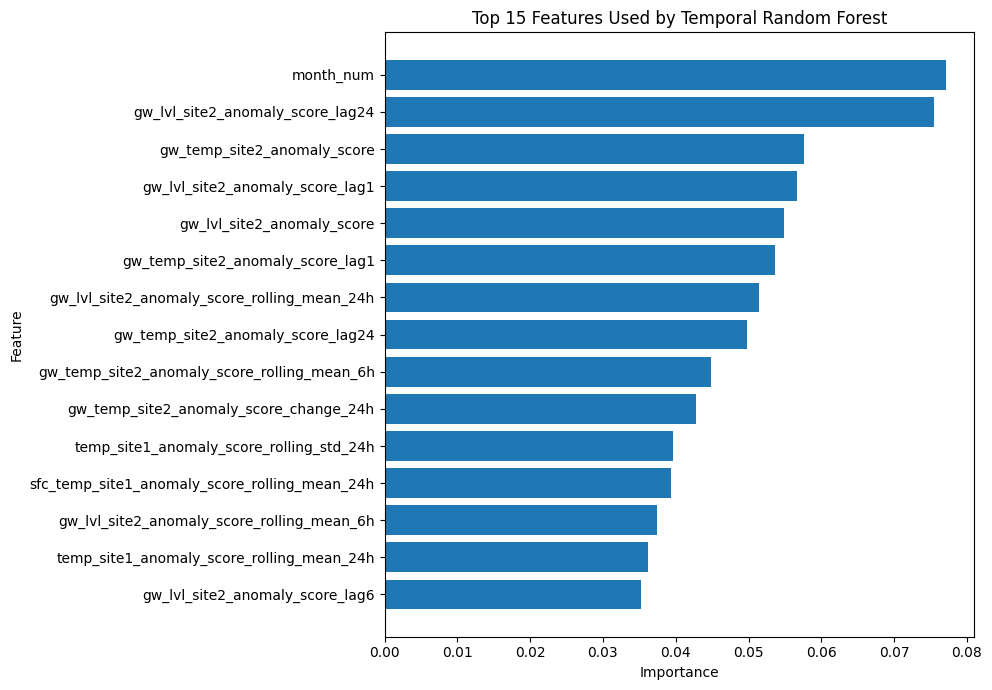

In [ ]:
# ============================================================
# VISUALIZE TOP 15 FEATURE IMPORTANCE
# ============================================================

import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Used by Temporal Random Forest")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PERMUTATION IMPORTANCE — VALIDATION SET
# ============================================================

from sklearn.inspection import permutation_importance

print("Calculating permutation importance...")
print("This may take a little while...")

perm_result = permutation_importance(
    validation_rf,
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

perm_importance = perm_importance.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

print("\nTop 20 features by permutation importance:")
print(
    perm_importance.head(20).to_string(index=False)
)

Calculating permutation importance...
This may take a little while...

Top 20 features by permutation importance:
                                     feature  importance_mean  importance_std
           gw_temp_site2_anomaly_score_lag24         0.065398        0.003043
   temp_site1_anomaly_score_rolling_mean_24h         0.045178        0.004087
      gw_temp_site2_anomaly_score_change_24h         0.022505        0.003676
            gw_temp_site2_anomaly_score_lag1         0.015923        0.001345
gw_temp_site2_anomaly_score_rolling_mean_24h         0.013289        0.004201
                  gw_lvl_site2_anomaly_score         0.010511        0.004257
                 gw_temp_site2_anomaly_score         0.010002        0.002414
            gw_temp_site2_anomaly_score_lag6         0.008770        0.001861
       gw_lvl_site2_anomaly_score_change_24h         0.008089        0.002008
 gw_temp_site2_anomaly_score_rolling_mean_6h         0.007576        0.001804
    temp_site1_anomaly_score

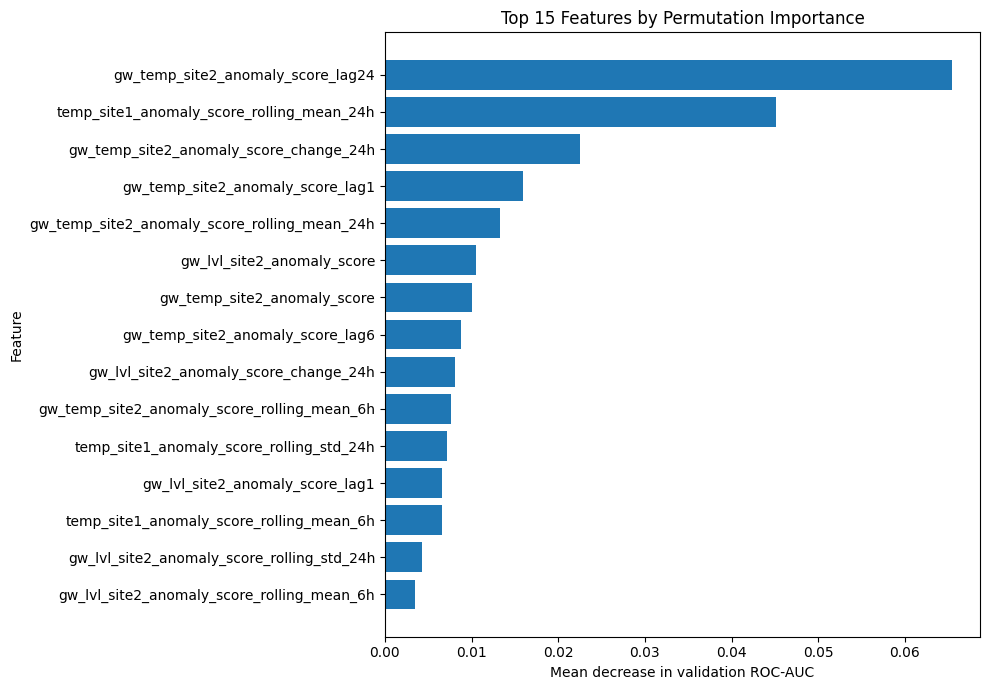

In [ ]:
# ============================================================
# PERMUTATION IMPORTANCE VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

top_perm = perm_importance.head(15).sort_values(
    "importance_mean",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_perm["feature"],
    top_perm["importance_mean"]
)

plt.xlabel("Mean decrease in validation ROC-AUC")
plt.ylabel("Feature")
plt.title("Top 15 Features by Permutation Importance")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SAVE FINAL MODEL + CONFIGURATION
# ============================================================

import joblib
import json
import os

# Create a project folder in Google Drive
project_dir = "/content/drive/MyDrive/Smart_Water_Monitoring"

os.makedirs(project_dir, exist_ok=True)

# ------------------------------------------------------------
# 1. Save trained model
# ------------------------------------------------------------

model_path = os.path.join(
    project_dir,
    "temporal_random_forest.joblib"
)

joblib.dump(validation_rf, model_path)

# ------------------------------------------------------------
# 2. Save model configuration
# ------------------------------------------------------------

model_config = {
    "model_name": "Temporal Random Forest",
    "threshold": float(best_threshold),
    "features": features,
    "temporal_features": [
        "gw_lvl_site2_anomaly_score",
        "gw_temp_site2_anomaly_score",
        "temp_site1_anomaly_score",
        "sfc_temp_site1_anomaly_score"
    ],
    "lag_windows": [1, 6, 24],
    "rolling_windows": [6, 24],
    "dataset_shape": list(df.shape),
    "training_samples": len(X_train_model),
    "validation_samples": len(X_val),
    "test_samples": len(X_test)
}

config_path = os.path.join(
    project_dir,
    "model_config.json"
)

with open(config_path, "w") as f:
    json.dump(model_config, f, indent=4)

print("=" * 60)
print("MODEL SAVED SUCCESSFULLY")
print("=" * 60)

print("\nModel:")
print(model_path)

print("\nConfiguration:")
print(config_path)

print("\nNumber of features:", len(features))
print("Selected threshold:", best_threshold)

MODEL SAVED SUCCESSFULLY

Model:
/content/drive/MyDrive/Smart_Water_Monitoring/temporal_random_forest.joblib

Configuration:
/content/drive/MyDrive/Smart_Water_Monitoring/model_config.json

Number of features: 57
Selected threshold: 0.65


In [ ]:
# ============================================================
# VERIFY SAVED MODEL
# ============================================================

print("Model file exists:",
      os.path.exists(model_path))

print("Config file exists:",
      os.path.exists(config_path))

print("\nFiles in project folder:")
print(os.listdir(project_dir))

Model file exists: True
Config file exists: True

Files in project folder:
['temporal_random_forest.joblib', 'model_config.json']


In [ ]:
# ============================================================
# REUSABLE PREDICTION FUNCTION
# ============================================================

import joblib
import json
import pandas as pd
import numpy as np

# Load saved model
saved_model = joblib.load(model_path)

# Load configuration
with open(config_path, "r") as f:
    saved_config = json.load(f)

saved_features = saved_config["features"]
saved_threshold = saved_config["threshold"]

print("Saved model loaded successfully.")
print("Expected features:", len(saved_features))
print("Threshold:", saved_threshold)

Saved model loaded successfully.
Expected features: 57
Threshold: 0.65


In [ ]:
# ============================================================
# TEMPORAL FEATURE FUNCTION
# ============================================================

def create_temporal_features(data):

    data = data.copy()

    # Convert timestamp
    data["timestamp"] = pd.to_datetime(
        data["timestamp"],
        format="%d-%m-%Y %H:%M"
    )

    # Sort chronologically
    data = data.sort_values("timestamp").reset_index(drop=True)

    temporal_features = [
        "gw_lvl_site2_anomaly_score",
        "gw_temp_site2_anomaly_score",
        "temp_site1_anomaly_score",
        "sfc_temp_site1_anomaly_score"
    ]

    # Time features
    data["hour"] = data["timestamp"].dt.hour
    data["day_of_week"] = data["timestamp"].dt.dayofweek
    data["month_num"] = data["timestamp"].dt.month

    # Cyclical encoding
    data["hour_sin"] = np.sin(
        2 * np.pi * data["hour"] / 24
    )

    data["hour_cos"] = np.cos(
        2 * np.pi * data["hour"] / 24
    )

    data["dow_sin"] = np.sin(
        2 * np.pi * data["day_of_week"] / 7
    )

    data["dow_cos"] = np.cos(
        2 * np.pi * data["day_of_week"] / 7
    )

    # Lag and rolling features
    for col in temporal_features:

        data[f"{col}_lag1"] = data[col].shift(1)
        data[f"{col}_lag6"] = data[col].shift(6)
        data[f"{col}_lag24"] = data[col].shift(24)

        data[f"{col}_rolling_mean_6h"] = (
            data[col]
            .shift(1)
            .rolling(6, min_periods=1)
            .mean()
        )

        data[f"{col}_rolling_mean_24h"] = (
            data[col]
            .shift(1)
            .rolling(24, min_periods=1)
            .mean()
        )

        data[f"{col}_rolling_std_24h"] = (
            data[col]
            .shift(1)
            .rolling(24, min_periods=2)
            .std()
        )

        data[f"{col}_change_1h"] = (
            data[col] - data[col].shift(1)
        )

        data[f"{col}_change_24h"] = (
            data[col] - data[col].shift(24)
        )

    return data

print("Temporal feature function created.")

Temporal feature function created.


In [ ]:
# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_water_risk(data):

    # Create the same temporal features used during training
    processed_data = create_temporal_features(data)

    # Check that all expected features exist
    missing_features = [
        feature
        for feature in saved_features
        if feature not in processed_data.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing required features: {missing_features}"
        )

    # Keep EXACTLY the same feature order used during training
    X_new = processed_data[saved_features]

    # Predict probability
    probability = saved_model.predict_proba(X_new)[:, 1]

    # Apply threshold selected on validation data
    prediction = (
        probability >= saved_threshold
    ).astype(int)

    # Build result table
    results = pd.DataFrame({
        "timestamp": processed_data["timestamp"],
        "leak_probability": probability,
        "prediction": prediction
    })

    results["status"] = results["prediction"].map({
        0: "Normal",
        1: "Potential Leak"
    })

    return results

print("Prediction function created successfully.")

Prediction function created successfully.


In [ ]:
# ============================================================
# TEST THE PREDICTION PIPELINE
# ============================================================

test_sample = df.iloc[:100].copy()

prediction_results = predict_water_risk(test_sample)

print("Prediction pipeline working!")
print("\nFirst 10 predictions:")
print(prediction_results.head(10).to_string(index=False))

Prediction pipeline working!

First 10 predictions:
          timestamp  leak_probability  prediction status
2021-12-31 23:00:00          0.534888           0 Normal
2022-01-01 00:00:00          0.405596           0 Normal
2022-01-01 01:00:00          0.123824           0 Normal
2022-01-01 02:00:00          0.019106           0 Normal
2022-01-01 03:00:00          0.017570           0 Normal
2022-01-01 04:00:00          0.014629           0 Normal
2022-01-01 05:00:00          0.030423           0 Normal
2022-01-01 06:00:00          0.005648           0 Normal
2022-01-01 07:00:00          0.013771           0 Normal
2022-01-01 08:00:00          0.005374           0 Normal


In [ ]:
# ============================================================
# GENERATE FULL DATASET PREDICTIONS
# ============================================================

full_predictions = predict_water_risk(df)

print("Full prediction dataset created.")

print("\nShape:")
print(full_predictions.shape)

print("\nPrediction distribution:")
print(full_predictions["status"].value_counts())

print("\nAverage leak probability:",
      round(full_predictions["leak_probability"].mean(), 4))

print("\nHighest-risk observations:")
print(
    full_predictions
    .sort_values("leak_probability", ascending=False)
    .head(10)
    .to_string(index=False)
)

Full prediction dataset created.

Shape:
(8737, 4)

Prediction distribution:
status
Potential Leak    6672
Normal            2065
Name: count, dtype: int64

Average leak probability: 0.751

Highest-risk observations:
          timestamp  leak_probability  prediction         status
2022-06-19 18:00:00               1.0           1 Potential Leak
2022-06-19 08:00:00               1.0           1 Potential Leak
2022-06-19 20:00:00               1.0           1 Potential Leak
2022-06-19 07:00:00               1.0           1 Potential Leak
2022-06-19 09:00:00               1.0           1 Potential Leak
2022-06-19 10:00:00               1.0           1 Potential Leak
2022-06-19 11:00:00               1.0           1 Potential Leak
2022-06-19 12:00:00               1.0           1 Potential Leak
2022-06-20 10:00:00               1.0           1 Potential Leak
2022-06-20 11:00:00               1.0           1 Potential Leak


In [ ]:
# ============================================================
# CREATE APPLICATION FOLDER
# ============================================================

import os
import shutil

app_dir = "/content/Smart_Water_Monitoring"

os.makedirs(app_dir, exist_ok=True)

# Copy application
shutil.copy(
    "/content/app.py",
    f"{app_dir}/app.py"
)

# Copy trained model
shutil.copy(
    model_path,
    f"{app_dir}/temporal_random_forest.joblib"
)

# Copy configuration
shutil.copy(
    config_path,
    f"{app_dir}/model_config.json"
)

print("Application folder created successfully!")
print("\nFiles:")

for file in os.listdir(app_dir):
    print("-", file)

Application folder created successfully!

Files:
- temporal_random_forest.joblib
- app.py
- model_config.json


In [ ]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-usw1b1-2p6nhryf6anay-b.us-west1-1.prod.colab.dev


In [ ]:
!curl -I http://127.0.0.1:8501

HTTP/1.1 200 OK
date: Sun, 30 Aug 2026 16:06:04 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 11141
last-modified: Sun, 30 Aug 2026 15:37:29 GMT
etag: "554329179581e7a74696412cbe495d78"
cache-control: no-cache



In [ ]:
from google.colab import output

output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501, height=800)

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# FINAL APPLICATION PIPELINE TEST
# ============================================================

import os
import pandas as pd
import numpy as np
import joblib
import json

APP_DIR = "/content/Smart_Water_Monitoring"

MODEL_PATH = f"{APP_DIR}/temporal_random_forest.joblib"
CONFIG_PATH = f"{APP_DIR}/model_config.json"
DATA_PATH = "/content/water_data.csv"

print("Checking project files...")
print("app.py:", os.path.exists(f"{APP_DIR}/app.py"))
print("Model:", os.path.exists(MODEL_PATH))
print("Config:", os.path.exists(CONFIG_PATH))
print("Dataset:", os.path.exists(DATA_PATH))

# Load model and config
model = joblib.load(MODEL_PATH)

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

FEATURES = config["features"]
THRESHOLD = config["threshold"]

print("\nModel loaded successfully.")
print("Number of required features:", len(FEATURES))
print("Threshold:", THRESHOLD)

# Load real dataset
df_test = pd.read_csv(DATA_PATH)

print("\nDataset loaded.")
print("Shape:", df_test.shape)

# ------------------------------------------------------------
# TEMPORAL FEATURE FUNCTION
# ------------------------------------------------------------

def create_temporal_features(data):

    data = data.copy()

    data["timestamp"] = pd.to_datetime(data["timestamp"])

    data = data.sort_values("timestamp").reset_index(drop=True)

    temporal_features = [
        "gw_lvl_site2_anomaly_score",
        "gw_temp_site2_anomaly_score",
        "temp_site1_anomaly_score",
        "sfc_temp_site1_anomaly_score"
    ]

    data["hour"] = data["timestamp"].dt.hour
    data["day_of_week"] = data["timestamp"].dt.dayofweek
    data["month_num"] = data["timestamp"].dt.month

    data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
    data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)

    data["dow_sin"] = np.sin(2 * np.pi * data["day_of_week"] / 7)
    data["dow_cos"] = np.cos(2 * np.pi * data["day_of_week"] / 7)

    for col in temporal_features:

        data[f"{col}_lag1"] = data[col].shift(1)
        data[f"{col}_lag6"] = data[col].shift(6)
        data[f"{col}_lag24"] = data[col].shift(24)

        data[f"{col}_rolling_mean_6h"] = (
            data[col].shift(1)
            .rolling(6, min_periods=1)
            .mean()
        )

        data[f"{col}_rolling_mean_24h"] = (
            data[col].shift(1)
            .rolling(24, min_periods=1)
            .mean()
        )

        data[f"{col}_rolling_std_24h"] = (
            data[col].shift(1)
            .rolling(24, min_periods=2)
            .std()
        )

        data[f"{col}_change_1h"] = (
            data[col] - data[col].shift(1)
        )

        data[f"{col}_change_24h"] = (
            data[col] - data[col].shift(24)
        )

    return data


# Create features
processed = create_temporal_features(df_test)

print("Temporal features created.")

# Check required features
missing_features = [
    f for f in FEATURES
    if f not in processed.columns
]

print("Missing required features:", len(missing_features))

if missing_features:
    print(missing_features)
    raise ValueError("Required model features are missing.")

# Prepare model input
X = processed[FEATURES]

print("Model input shape:", X.shape)

# Predict
probabilities = model.predict_proba(X)[:, 1]

predictions = (
    probabilities >= THRESHOLD
).astype(int)

print("\n======================================================")
print("APPLICATION PIPELINE TEST")
print("======================================================")

print("Predictions generated:", len(predictions))
print("Average probability:", round(probabilities.mean(), 4))
print("Potential Leak-Proximity:", predictions.sum())
print("Normal:", len(predictions) - predictions.sum())

print("\nFirst 10 predictions:")

result = pd.DataFrame({
    "timestamp": processed["timestamp"],
    "leak_probability": probabilities,
    "prediction": predictions
})

result["status"] = result["prediction"].map({
    0: "Normal",
    1: "Potential Leak-Proximity"
})

print(result.head(10).to_string(index=False))

print("\nAPPLICATION PIPELINE TEST PASSED.")

Checking project files...
app.py: True
Model: True
Config: True
Dataset: True

Model loaded successfully.
Number of required features: 57
Threshold: 0.65

Dataset loaded.
Shape: (8737, 20)


/tmp/ipykernel_1208/2135274274.py:50: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data["timestamp"] = pd.to_datetime(data["timestamp"])


Temporal features created.
Missing required features: 0
Model input shape: (8737, 57)

APPLICATION PIPELINE TEST
Predictions generated: 8737
Average probability: 0.751
Potential Leak-Proximity: 6672
Normal: 2065

First 10 predictions:
          timestamp  leak_probability  prediction status
2021-12-31 23:00:00          0.534888           0 Normal
2022-01-01 00:00:00          0.405596           0 Normal
2022-01-01 01:00:00          0.123824           0 Normal
2022-01-01 02:00:00          0.019106           0 Normal
2022-01-01 03:00:00          0.017570           0 Normal
2022-01-01 04:00:00          0.014629           0 Normal
2022-01-01 05:00:00          0.030423           0 Normal
2022-01-01 06:00:00          0.005648           0 Normal
2022-01-01 07:00:00          0.013771           0 Normal
2022-01-01 08:00:00          0.005374           0 Normal

APPLICATION PIPELINE TEST PASSED.


In [ ]:
data["timestamp"] = pd.to_datetime(
    data["timestamp"],
    dayfirst=True
)

NameError: name 'data' is not defined

In [ ]:
# Fix timestamp parsing inside app.py

app_path = "/content/Smart_Water_Monitoring/app.py"

with open(app_path, "r") as f:
    app_text = f.read()

app_text = app_text.replace(
    'data["timestamp"] = pd.to_datetime(data["timestamp"])',
    '''data["timestamp"] = pd.to_datetime(
        data["timestamp"],
        dayfirst=True
    )'''
)

with open(app_path, "w") as f:
    f.write(app_text)

print("app.py timestamp parsing fixed.")

app.py timestamp parsing fixed.


In [ ]:
!grep -A3 'data\["timestamp"\]' /content/Smart_Water_Monitoring/app.py

    data["timestamp"] = pd.to_datetime(
        data["timestamp"],
        dayfirst=True
    )

--
    data["hour"] = data["timestamp"].dt.hour
    data["day_of_week"] = data["timestamp"].dt.dayofweek
    data["month_num"] = data["timestamp"].dt.month

    # Cyclical encoding
    data["hour_sin"] = np.sin(
--
            "timestamp": processed_data["timestamp"],
            "leak_probability": probabilities,
            "prediction": predictions
        })


In [ ]:
from google.colab import output

url = output.eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-usw1b1-2p6nhryf6anay-b.us-west1-1.prod.colab.dev


In [ ]:
MODEL_PATH = "temporal_random_forest.joblib"
CONFIG_PATH = "model_config.json"

In [ ]:
app_path = "/content/Smart_Water_Monitoring/app.py"

with open(app_path, "r") as f:
    app_text = f.read()

app_text = app_text.replace(
    'MODEL_PATH = "temporal_random_forest.joblib"',
    'MODEL_PATH = "/content/Smart_Water_Monitoring/temporal_random_forest.joblib"'
)

app_text = app_text.replace(
    'CONFIG_PATH = "model_config.json"',
    'CONFIG_PATH = "/content/Smart_Water_Monitoring/model_config.json"'
)

with open(app_path, "w") as f:
    f.write(app_text)

print("Model and config paths fixed.")

Model and config paths fixed.


In [ ]:
# Fix the broken tabs line in app.py

app_path = "/content/Smart_Water_Monitoring/app.py"

with open(app_path, "r") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "tab1, tab2, tab3, tab4 =" in line:
        lines[i] = 'tab1, tab2, tab3, tab4 = st.tabs(["📈 Risk Trend", "🚨 High-Risk Events", "📋 Predictions", "ℹ️ Model Information"])\n'
        print(f"Fixed line {i + 1}")

with open(app_path, "w") as f:
    f.writelines(lines)

print("app.py tabs syntax fixed.")

Fixed line 520
app.py tabs syntax fixed.


In [ ]:
!python -m py_compile /content/Smart_Water_Monitoring/app.py

In [ ]:
!sed -n '500,650p' /content/Smart_Water_Monitoring/app.py

            "decision threshold."
        )


with probability_col:

    st.metric(
        "Latest Risk Score",
        f"{latest['leak_probability']:.1%}"
    )

    st.caption(
        f"Timestamp: {latest['timestamp']}"
    )


# ============================================================
# TABS
# ============================================================

tab1, tab2, tab3, tab4 = st.tabs(["📈 Risk Trend", "🚨 High-Risk Events", "📋 Predictions", "ℹ️ Model Information"])
# ============================================================
# MONITORING SIMULATION
# ============================================================

if monitoring_mode == "Monitoring Simulation":

    st.divider()
    st.subheader("📡 Monitoring Simulation")

    st.caption(
        "Historical sensor observations are replayed chronologically "
        "to simulate incoming hourly monitoring data."
    )

    if "simulation_index" not in st.session_state:
        st.session_state.simulation_index = len(results) - 